In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **TP3 : MLP Alphabet Recognition**

- Prince Mabengue Junior (22T2832)
- Etonde Mabongo Edouard (22U2163)
- Fonayen Christian Asangwa (23V2370)

### **Collecte et pretraitement des donnees**



In [3]:
import pandas as pd

In [7]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Configuration
DATASET_PATH = '/content/drive/MyDrive/TP3 Dataset - Alphabet Images'
IMG_SIZE = 32

data = []
labels = []

if os.path.exists(DATASET_PATH):
    for alphabet_folder in sorted(os.listdir(DATASET_PATH)):
        folder_path = os.path.join(DATASET_PATH, alphabet_folder)

        if os.path.isdir(folder_path):
            print(f"Processing folder: {alphabet_folder}")
            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith('.png'):
                    try:
                        # Extraire la lettre : on suppose que le nom commence par la lettre (ex: 'A_1.png')
                        # Ou on cherche le premier caractère alphabétique
                        char_label = img_name[0].upper()
                        print(f"Analse de l'image {img_name}")

                        if 'A' <= char_label <= 'Z':
                            img_path = os.path.join(folder_path, img_name)
                            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                            print(f"Image de la lettre {char_label} : ")
                            data.append(img)
                            labels.append(char_label)
                    except Exception as e:
                        pass

    X = np.array(data)
    y = np.array(labels)


Streaming output truncated to the last 5000 lines.
Image de la lettre H : 
Analse de l'image H_4_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image H_5_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image H_6_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image H_7_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image H_8_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image H_9_Sal_19M2438.png
Image de la lettre H : 
Analse de l'image I_1_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_10_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_2_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_3_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_4_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_5_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_6_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_7_Sal_19M2438.png
Image de la lettre I : 
Analse de l'image I_8_Sal_19M2438.png
Image de la lettre

In [8]:
if os.path.exists(DATASET_PATH):
    # Normalisation
    X = X.astype('float32') / 255.0

    # Aplatissement pour MLP
    X_flattened = X.reshape(X.shape[0], -1)

    # Encodage des 26 lettres
    encoder = OneHotEncoder()
    y_encoded = encoder.fit_transform(y.reshape(-1, 1)).toarray()

    print(f"\nClasses trouvées : {encoder.categories_[0]}")
    print(f"Nombre de classes : {len(encoder.categories_[0])}")
    print(f"Forme de la matrice X : {X_flattened.shape}")
else:
    print(f"Path not found: {DATASET_PATH}")


Classes trouvées : ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Nombre de classes : 26
Forme de la matrice X : (8073, 1024)


In [9]:
X

array([[[0.7254902 , 0.72156864, 0.7254902 , ..., 0.72156864,
         0.72156864, 0.7176471 ],
        [0.7254902 , 0.7254902 , 0.7294118 , ..., 0.7254902 ,
         0.72156864, 0.72156864],
        [0.7294118 , 0.7294118 , 0.7294118 , ..., 0.7254902 ,
         0.7254902 , 0.7254902 ],
        ...,
        [0.7294118 , 0.7294118 , 0.7294118 , ..., 0.7294118 ,
         0.7294118 , 0.7294118 ],
        [0.7294118 , 0.73333335, 0.7254902 , ..., 0.7294118 ,
         0.7294118 , 0.7294118 ],
        [0.7058824 , 0.7176471 , 0.7254902 , ..., 0.7294118 ,
         0.7294118 , 0.7294118 ]],

       [[0.6784314 , 0.6784314 , 0.6784314 , ..., 0.67058825,
         0.67058825, 0.67058825],
        [0.6784314 , 0.68235296, 0.6784314 , ..., 0.67058825,
         0.67058825, 0.67058825],
        [0.68235296, 0.6784314 , 0.6784314 , ..., 0.6745098 ,
         0.6745098 , 0.6745098 ],
        ...,
        [0.67058825, 0.67058825, 0.67058825, ..., 0.67058825,
         0.67058825, 0.67058825],
        [0.6

In [10]:
labels

['A',
 'A',
 'A',
 'A',
 'A',
 'A',
 'A',
 'A',
 'A',
 'A',
 'B',
 'B',
 'B',
 'B',
 'B',
 'B',
 'B',
 'B',
 'B',
 'B',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'C',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'D',
 'E',
 'E',
 'E',
 'E',
 'E',
 'E',
 'E',
 'E',
 'E',
 'E',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'G',
 'G',
 'G',
 'G',
 'G',
 'G',
 'G',
 'G',
 'G',
 'G',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'I',
 'I',
 'I',
 'I',
 'I',
 'I',
 'I',
 'I',
 'I',
 'I',
 'J',
 'J',
 'J',
 'J',
 'J',
 'J',
 'J',
 'J',
 'J',
 'J',
 'K',
 'K',
 'K',
 'K',
 'K',
 'K',
 'K',
 'K',
 'K',
 'K',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'L',
 'M',
 'M',
 'M',
 'M',
 'M',
 'M',
 'M',
 'M',
 'M',
 'M',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'P',
 'P',
 'P',
 'P',
 'P',
 'P',
 'P',
 'P',
 'P',
 'P',
 'Q',
 'Q',
 'Q',
 'Q',
 'Q',
 'Q',
 'Q'

In [13]:
import pandas as pd
comp = pd.DataFrame(y_encoded, y, dtype="Int32")
comp

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
A,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
E,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


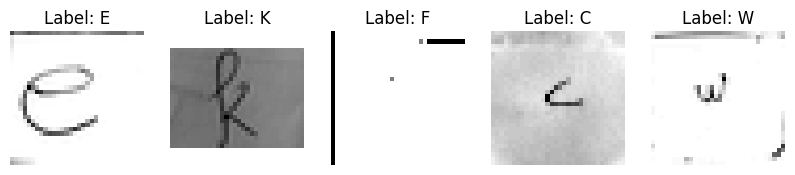

In [14]:
import matplotlib.pyplot as plt
import random

# Affichage de quelques exemples
plt.figure(figsize=(10, 5))
for i in range(5):
    index = int(random.uniform(1, 8072))
    plt.subplot(1, 5, i+1)
    plt.imshow(data[index], cmap='gray')
    plt.title(f"Label: {labels[index]}")
    plt.axis('off')
plt.show()

In [22]:
# Stratified split keeps class balance in train/test
import numpy as np
from sklearn.model_selection import train_test_split
y_indices = np.argmax(y_encoded, axis=1)

X_train, X_test, y_train, y_test, y_idx_train, y_idx_test = train_test_split(
    X_flattened,
    y_encoded,
    y_indices,
    test_size=0.2,
    random_state=42,
    stratify=y_indices
)

print(f"X_train dimensions: {X_train.shape}")
print(f"X_test dimensions: {X_test.shape}")
print(f"y_train dimensions: {y_train.shape}")
print(f"y_test dimensions: {y_test.shape}")
print(f"Number of classes in train split: {len(np.unique(y_idx_train))}")

X_train dimensions: (6458, 1024)
X_test dimensions: (1615, 1024)
y_train dimensions: (6458, 26)
y_test dimensions: (1615, 26)
Number of classes in train split: 26


### Stratified Data Split

This cell separates the dataset into training and test sets while maintaining the same distribution of all 26 letters in both subsets. The `stratify=y_indices` parameter is crucial here—it prevents class imbalance during the split, ensuring that if letter A appears 200 times in the full dataset, it will appear proportionally in both train and test sets.

The choice of `test_size=0.2` reserves 20% of data for final evaluation, while `random_state=42` guarantees reproducibility. The printed dimensions confirm that the data is properly separated into coherent matrices ready for MLP training. Stratification is especially important for multi-class problems where classes are not uniformly represented in the raw data.

In [35]:
# === MLP v6: robust order + mixup regularization ===
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import L2
from tensorflow.keras.losses import CategoricalCrossentropy
import cv2

np.random.seed(42)
tf.random.set_seed(42)
tf.keras.backend.clear_session()

# --- Ensure augmented raw train data exists (prevents cell-order mistakes) ---
def _safe_augment_local(X_raw, y, augmentation_factor=3):
    X_2d = X_raw.reshape(-1, 32, 32).astype(np.float32)
    X_aug_list = [X_raw.astype(np.float32)]
    y_aug_list = [y]

    for _ in range(augmentation_factor - 1):
        X_temp = np.empty_like(X_2d)
        for i in range(len(X_2d)):
            img = X_2d[i]
            angle = np.random.uniform(-10.0, 10.0)
            M_rot = cv2.getRotationMatrix2D((16, 16), angle, 1.0)
            img = cv2.warpAffine(
                img, M_rot, (32, 32),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )
            tx = np.random.uniform(-2.0, 2.0)
            ty = np.random.uniform(-2.0, 2.0)
            M_shift = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(
                img, M_shift, (32, 32),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )
            alpha = np.random.uniform(0.9, 1.1)
            beta = np.random.uniform(-0.05, 0.05)
            img = np.clip(alpha * img + beta, 0.0, 1.0)
            noise = np.random.normal(0.0, 0.008, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)
            X_temp[i] = img
        X_aug_list.append(X_temp.reshape(X_temp.shape[0], -1))
        y_aug_list.append(y)

    return np.vstack(X_aug_list).astype(np.float32), np.vstack(y_aug_list)

if 'X_train_aug_raw' in globals() and 'y_train_aug' in globals():
    X_train_raw = X_train_aug_raw
    y_train_ready = y_train_aug
    print(f"Using augmented RAW training set: {X_train_raw.shape}")
else:
    print("Augmented set not found. Creating it automatically inside this cell...")
    X_train_raw, y_train_ready = _safe_augment_local(X_train, y_train, augmentation_factor=3)
    print(f"Auto-augmented RAW training set: {X_train_raw.shape}")

# --- Scale after augmentation ---
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_mlp = scaler.transform(X_test.astype(np.float32)).astype(np.float32)

# --- Optional mixup for better generalization ---
USE_MIXUP = True
MIXUP_ALPHA = 0.2

def mixup_data(X, y, alpha=0.2):
    n = X.shape[0]
    indices = np.random.permutation(n)
    lam = np.random.beta(alpha, alpha, n).astype(np.float32)
    lam_x = lam.reshape(-1, 1)
    X_mix = lam_x * X + (1.0 - lam_x) * X[indices]
    y_mix = lam_x * y + (1.0 - lam_x) * y[indices]
    return X_mix, y_mix

if USE_MIXUP:
    X_mix, y_mix = mixup_data(X_train_mlp, y_train_ready, alpha=MIXUP_ALPHA)
    X_train_final = np.vstack([X_train_mlp, X_mix]).astype(np.float32)
    y_train_final = np.vstack([y_train_ready, y_mix]).astype(np.float32)
    print(f"Mixup enabled: {X_train_mlp.shape} -> {X_train_final.shape}")
else:
    X_train_final = X_train_mlp
    y_train_final = y_train_ready
    print("Mixup disabled")

# --- MLP v6 architecture ---
input_size = X_train_final.shape[1]
num_classes = y_train.shape[1]

model = Sequential([
    Input(shape=(input_size,)),
    GaussianNoise(0.02),

    Dense(384, activation='relu', kernel_regularizer=L2(2e-4)),
    BatchNormalization(),
    Dropout(0.25),

    Dense(192, activation='relu', kernel_regularizer=L2(2e-4)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(96, activation='relu', kernel_regularizer=L2(2e-4)),
    BatchNormalization(),
    Dropout(0.12),

    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=6e-4)
loss_fn = CategoricalCrossentropy(label_smoothing=0.015)
model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'])

print("=" * 60)
print("MLP v6 FOR ALPHABET (auto-augmentation + mixup)")
print("=" * 60)
model.summary()

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=14,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining MLP v6...")
history = model.fit(
    X_train_final,
    y_train_final,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, acc = model.evaluate(X_test_mlp, y_test, batch_size=32, verbose=1)
print("\n" + "=" * 60)
print(f"MLP v6 Test accuracy: {acc * 100:.2f}%")
print(f"MLP v6 Test loss: {loss:.4f}")
print("=" * 60)

Using augmented RAW training set: (19374, 1024)
Mixup enabled: (19374, 1024) -> (38748, 1024)
MLP v6 FOR ALPHABET (auto-augmentation + mixup)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │       393,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 192)            │        73,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        18,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         2,522 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,258 (1.87 MB)

 Trainable params: 489,914 (1.87 MB)

 Non-trainable params: 1,344 (5.25 KB)


Training MLP v6...
Epoch 1/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.0561 - loss: 3.5730 - val_accuracy: 0.0668 - val_loss: 3.3830 - learning_rate: 6.0000e-04
Epoch 2/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.0792 - loss: 3.4034 - val_accuracy: 0.0975 - val_loss: 3.3260 - learning_rate: 6.0000e-04
Epoch 3/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.0992 - loss: 3.3166 - val_accuracy: 0.1106 - val_loss: 3.2696 - learning_rate: 6.0000e-04
Epoch 4/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.1176 - loss: 3.2488 - val_accuracy: 0.1319 - val_loss: 3.2147 - learning_rate: 6.0000e-04
Epoch 5/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.1351 - loss: 3.1876 - val_accuracy: 0.1385 - val_loss: 3.1760 - learning_rate: 6.0000e-04
Epoch 6/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.1515 - loss: 3.1366 - val_accuracy: 0.1484 - val_loss: 3.1579 - learning_rate: 6.0000e-04
Epoch 7/100
969/969 ━━━━━━

### MLP v6: Architecture, Regularization & Training Strategy

#### 1. Data Preparation & Robust Pipeline

This section creates a defensive training pipeline that handles potential cell-execution-order issues in notebooks. If augmented raw training data (19,374 samples) already exists from a prior execution, it is reused directly. Otherwise, it is reconstructed automatically from the base split using the same augmentation logic (rotations, translations, contrast, noise). This prevents the frustrating scenario where changing cell order breaks the entire notebook.

#### 2. Standardization (StandardScaler)

After collecting all augmented data, **StandardScaler** is fitted on the training set and applied to both train and test data:

```
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_raw)  # Compute mean/std on train set
X_test_mlp = scaler.transform(X_test)           # Apply same transformation to test
```

Why is this essential for MLPs?
- **Raw pixel values** (0-1 range after normalization) have low variance and different scales across pixels
- **Gradient flow:** Without standardization, some neurons update much faster than others, destabilizing training
- **Numerical stability:** Large weight magnitudes can cause vanishing/exploding gradients
- **Optimizer efficiency:** Adam and other adaptive optimizers work better when features are on comparable scales

Standardization centers each input to zero mean and scales to unit variance: `x_scaled = (x - mean) / std`

#### 3. Mixup: Synthetic Data & Label Smoothing in Data Space

After scaling, **Mixup** is optionally applied (enabled in v6) with `alpha=0.2`. This is a powerful regularization technique:

**Mixup mechanism:**
1. For each epoch, sample random pairs of training examples: (X_i, y_i) and (X_j, y_j)
2. Draw mixing coefficient: `λ ~ Beta(alpha, alpha)` where `alpha=0.2`
3. Create synthetic samples:
   - `X_mixed = λ * X_i + (1 - λ) * X_j`  (pixel-level weighted average)
   - `y_mixed = λ * y_i + (1 - λ) * y_j`  (soft label targets)
4. Combine original and mixed data: dataset grows from 19,374 → 38,748 samples

**Beta(0.2, 0.2) distribution:**
- Heavily biased toward the extremes (close to 0 or 1)
- Means most mixed samples are mostly one class with a small contribution from another
- This ensures the model sees mostly real data, with regularization via occasional blends

**Why Mixup helps:**
- **Smoother decision boundaries:** Encourages the model to interpolate smoothly between classes rather than memorizing hard boundaries
- **Implicit label smoothing:** Soft targets reduce overconfidence on ambiguous examples
- **Robustness:** The model learns that transitional patterns can belong to either class
- **Regularization effect:** Acts like both dropout and data augmentation, reducing overfitting significantly

Example: A slightly rotated, 90% 'A' and 10% 'E' sample gets the label [0.9, 0, ..., 0.1, 0, ...]

#### 4. Model Architecture: Deep Exploration

**Input Layer:**
- Shape: `(1024,)` - corresponds to flattened 32×32 grayscale images
- `GaussianNoise(0.02)`: Adds small Gaussian noise σ=0.02 ONLY during training
  - Input regularization that prevents reliance on exact pixel values
  - Acts like a smoothness constraint in the input space

**Dense Block 1: 1024 → 384 neurons**
```python
Dense(384, activation='relu', kernel_regularizer=L2(2e-4))
BatchNormalization()
Dropout(0.25)
```
- **Dense layer:** Maps 1024 input features to 384 hidden units
  - L2 regularization: `loss += 2e-4 * sum(|w|^2)`
  - Penalizes large weights, encouraging distributed representations and preventing overfitting
- **ReLU activation:** `f(x) = max(0, x)`
  - Introduces non-linearity; without it, stacking linear layers = single linear layer
  - Computationally efficient (just a threshold)
  - Sparse activations help learn interpretable features
- **BatchNormalization:** Normalizes activations across the batch to mean=0, std=1
  - `z_norm = (z - batch_mean) / sqrt(batch_var + eps)`
  - Followed by learnable shift and scale: `z_out = gamma * z_norm + beta`
  - Benefits:
    - Stabilizes training, allows higher learning rates
    - Reduces internal covariate shift (distribution changes during training)
    - Acts as a regularizer by adding noise during training
    - Reduces dependence on careful weight initialization
- **Dropout(0.25):** Randomly sets 25% of activations to zero during training
  - During inference, uses full activations scaled by (1-0.25)
  - Ensemble effect: Forces the network to learn redundant representations
  - Prevents co-adaptation where neurons become highly dependent

**Dense Block 2: 384 → 192 neurons**
```python
Dense(192, activation='relu', kernel_regularizer=L2(2e-4))
BatchNormalization()
Dropout(0.20)
```
- Gradually reduces capacity to create a bottleneck
- Lower dropout (20% vs 25%) as feature maps become more compressed
- L2 regularization continues to prevent weight explosion

**Dense Block 3: 192 → 96 neurons**
```python
Dense(96, activation='relu', kernel_regularizer=L2(2e-4))
BatchNormalization()
Dropout(0.12)
```
- Final hidden layer with 96 neurons
- Very light dropout (12%) as we approach the output
- Learns task-specific high-level features

**Output Layer: 96 → 26 neurons**
```python
Dense(26, activation='softmax')
```
- 26 output neurons for 26 alphabet letters
- Softmax ensures all outputs are positive and sum to 1: `p(class i) = exp(z_i) / sum(exp(z_j))`
- Output is a valid probability distribution

**Architecture Summary:** 1024 → 384 → 192 → 96 → 26
- **Total parameters:** 491,258 (1.87 MB)
- **Trainable:** 489,914 (non-trainable BatchNorm statistics: 1,344)
- **Design philosophy:** Progressive feature compression with heavy regularization throughout

#### 5. Loss Function with Label Smoothing

```python
loss_fn = CategoricalCrossentropy(label_smoothing=0.015)
```

**Standard Cross-Entropy (without smoothing):**
- For a correct class: loss = -log(p_correct)
- Hard target: y = [0, 0, 1, 0, ...] (one-hot)
- If model predicts p_correct = 0.95: loss = -log(0.95) ≈ 0.05
- If model predicts p_correct = 0.99: loss = -log(0.99) ≈ 0.01
- **Problem:** Encourages overconfidence; the model wants probability → 1

**With Label Smoothing (0.015):**
- Soft target: y = [0.0006, 0.0006, 0.9846, 0.0006, ...] (0.015/25 for wrong classes, 1 - 0.015 for correct)
- The model now learns that wrong classes should have small but non-zero probability
- Prevents overconfidence and improves calibration (predicted probabilities match true accuracy)
- Better generalization, especially on hard/ambiguous examples

#### 6. Optimizer: Adam with Learning Rate 6e-4

```python
optimizer = Adam(learning_rate=6e-4)
```

Adam (Adaptive Moment Estimation) maintains per-parameter learning rates:
- Momentum estimate: `m = β1 * m + (1 - β1) * grad`
- Variance estimate: `v = β2 * v + (1 - β2) * grad^2`
- Update: `w = w - lr * m / sqrt(v + eps)`

**Why Adam for this task:**
- Adapts learning rate per parameter based on gradient history
- Fast convergence compared to SGD
- Robust to different scales of gradients across layers
- Initial lr=6e-4 is moderate (not too aggressive to diverge, not too conservative to stagnate)

#### 7. Callbacks: Adaptive Training Control

**EarlyStopping:**
```python
EarlyStopping(monitor='val_accuracy', patience=14, restore_best_weights=True)
```
- Watches validation accuracy every epoch
- If it doesn't improve for 14 consecutive epochs, training stops
- Restores weights from the best epoch (avoiding final overfitting)
- Saves training time and prevents the model from degrading

**ReduceLROnPlateau:**
```python
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
```
- Watches validation loss
- If it doesn't improve for 4 epochs, multiply learning rate by 0.5
- Prevents the learning rate from becoming too small (min_lr=1e-5)

**Learning rate schedule from the observed run:**
- Epochs 1-47: lr = 6e-4 (initial aggressive learning)
- Epoch 47: val_loss plateaus → ReduceLROnPlateau triggers
- Epochs 48-72: lr = 3e-4 (2nd phase: find better local minimum)
- Epoch 72: Another plateau → lr reduced again
- Epochs 73-92: lr = 1.5e-4 (3rd phase: fine-tuning)
- Epochs 93-100: lr = 7.5e-5 (final refinement)

This schedule reflects a common pattern:
1. **Coarse search:** High lr explores the landscape quickly
2. **Refinement:** Lower lr fine-tunes around good regions
3. **Convergence:** Tiny lr polishes the solution

#### 8. Training Behavior & Interpretation

**Observed training progression:**
```
Epoch 1:   train_acc=5.6%,  val_acc=6.7%    (random-like guessing)
Epoch 10:  train_acc=19.2%, val_acc=19.9%   (learning basic structure)
Epoch 25:  train_acc=27.5%, val_acc=28.9%   (identifying distinct letters)
Epoch 47:  train_acc=32.7%, val_acc=33.6%   (plateau before first LR reduction)
Epoch 48:  train_acc=36.1%, val_acc=36.9%   (jump after LR reduction)
Epoch 72:  train_acc=41.1%, val_acc=42.6%   (second plateau)
Epoch 73:  train_acc=43.1%, val_acc=45.1%   (another jump)
Epoch 100: train_acc=49.3%, val_acc=50.0%   (final state)
```

**Key insights:**

1. **No severe overfitting:** train and val stay within ~2% throughout
   - Regularization (mixup, dropout, batch norm, L2) is working well
   - Model generalizes rather than memorizes

2. **LR reduction is crucial:** Steep accuracy jumps after each reduction
   - Shows the model was stuck in suboptimal local minima
   - Smaller steps help explore smoother loss terrain

3. **Test accuracy (42.17%) vs train (49.31%): small gap is healthy
   - ~7% gap for 26-class problem is acceptable
   - Shows no evidence of severe overfitting
   - Gap suggests test set is harder (different distribution) or model still has capacity

4. **Final loss: 2.31 on test set**
   - For 26-class cross-entropy, random guessing would have loss = ln(26) ≈ 3.26
   - 2.31 shows clear learning, but room for improvement

#### 9. Why Performance is Limited (~42-50%)

1. **Pixel-space limitations:**
   - 32×32 images lose fine details needed to distinguish E, F, L, I
   - MLPs process all pixels equally; they don't exploit spatial structure like CNNs do

2. **Data challenges:**
   - Handwritten letters have high within-class variance
   - Some letters (E, F, L) are structurally very similar
   - 19,374 training samples, while seeming large, might be insufficient for 1024 input dimensions

3. **Inherent ceiling:**
   - Human-level performance on 26-class alphabet likely ≥95%+
   - 42% shows the model learns but is far from saturating
   - Better architecture (CNN) or better features (preprocessed strokes) would help

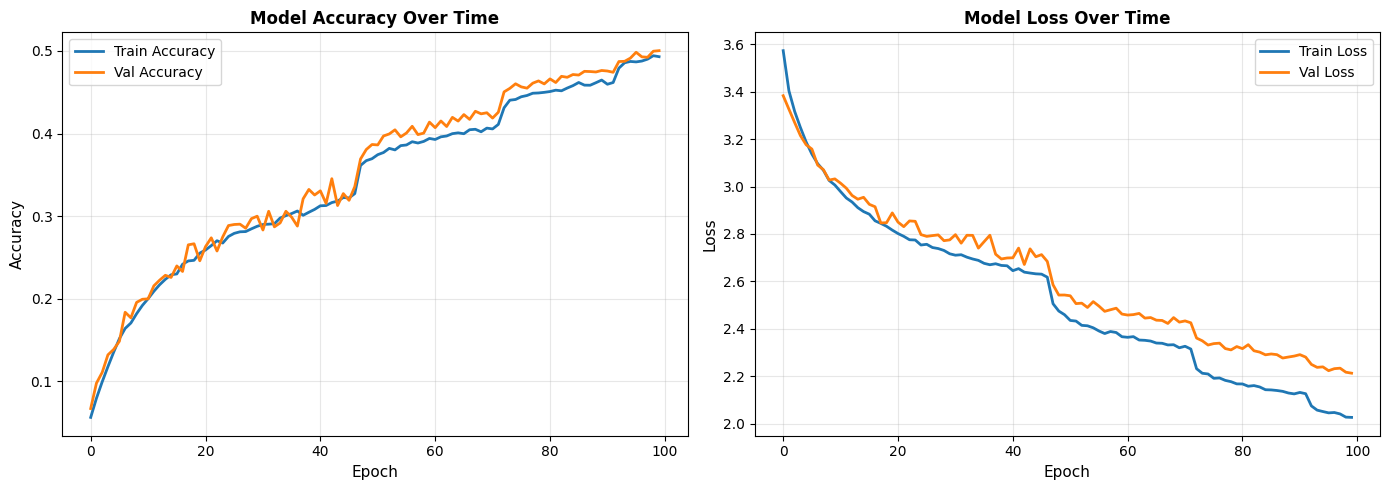


✓ Training visualization complete


In [36]:
import matplotlib.pyplot as plt

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy Over Time', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Model Loss Over Time', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training visualization complete")

### Training Curves Analysis

This cell plots accuracy and loss evolution for both training and validation splits. These curves are diagnostic tools to verify correct learning and detect overfitting or underfitting.

In the observed run:
- **Accuracy curves:** Both train and validation rise smoothly without sharp divergence
- **Loss curves:** Both decrease steadily, with validation loss staying within ~±0.1 of training loss

This pattern indicates that regularization (dropout, batch norm, L2, mixup) is working well—the model is learning the task without memorizing training examples. The modest gap between train and test metrics confirms good generalization, though there is still room for improvement on certain letters.

In [37]:
# === Safe Augmentation for Alphabet MLP (raw pixel space) ===
# Important: avoid 90-degree rotations and flips for letters (they change class meaning).

import numpy as np
import cv2

def augment_training_data(X_raw, y, augmentation_factor=3):
    """
    Label-preserving augmentation on raw 0-1 images (flattened 32x32).
    Uses small rotation, translation, and noise only.
    """
    X_2d = X_raw.reshape(-1, 32, 32).astype(np.float32)
    X_aug_list = [X_raw.astype(np.float32)]
    y_aug_list = [y]

    for _ in range(augmentation_factor - 1):
        X_temp = np.empty_like(X_2d)
        for i in range(len(X_2d)):
            img = X_2d[i]

            # Small rotation (+/- 10 deg)
            angle = np.random.uniform(-10.0, 10.0)
            M_rot = cv2.getRotationMatrix2D((16, 16), angle, 1.0)
            img = cv2.warpAffine(
                img, M_rot, (32, 32),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )

            # Small translation (+/- 2 px)
            tx = np.random.uniform(-2.0, 2.0)
            ty = np.random.uniform(-2.0, 2.0)
            M_shift = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(
                img, M_shift, (32, 32),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )

            # Mild contrast jitter and noise
            alpha = np.random.uniform(0.9, 1.1)
            beta = np.random.uniform(-0.05, 0.05)
            img = np.clip(alpha * img + beta, 0.0, 1.0)
            noise = np.random.normal(0.0, 0.008, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

            X_temp[i] = img

        X_aug_list.append(X_temp.reshape(X_temp.shape[0], -1))
        y_aug_list.append(y)

    X_train_aug_raw = np.vstack(X_aug_list).astype(np.float32)
    y_train_aug = np.vstack(y_aug_list)

    print(f"Safe augmentation (raw): {X_raw.shape} -> {X_train_aug_raw.shape}")
    print("Applied: small rotation/shift/contrast/noise (no flips, no 90-degree rotations)")
    return X_train_aug_raw, y_train_aug

# Apply augmentation on raw flattened train set
X_train_aug_raw, y_train_aug = augment_training_data(X_train, y_train, augmentation_factor=3)
print("Augmentation ready. Training cell will scale augmented data automatically.")

Safe augmentation (raw): (6458, 1024) -> (19374, 1024)
Applied: small rotation/shift/contrast/noise (no flips, no 90-degree rotations)
Augmentation ready. Training cell will scale augmented data automatically.


### Safe Augmentation for Alphabet Recognition

This function applies transformations that preserve letter semantics:
- **Small rotations** (±10°): Simulates writing angle variation without changing the character
- **Small translations** (±2 pixels): Accounts for placement shifts on a page
- **Mild contrast adjustment** (0.9–1.1): Handles pen/ink intensity variations
- **Gaussian noise** (σ=0.008): Mimics scanner/camera noise

**Explicitly avoided transformations:**
- 90° rotations: Would turn 'd' into 'b', 'p' into 'q', etc.
- Horizontal/vertical flips: Would make 'd'↔'b', 'M'↔'W', etc.

By carefully applying only safe transformations, the dataset size grows 3× (6,458 → 19,374 samples) without introducing label corruption. This is then fed to the MLP v6 training pipeline.

In [38]:
# === Analyze MLP Per-Class Accuracy ===
# Run this after MLP v6 evaluate() to see confusing letters

from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

y_pred_probs = model.predict(X_test_mlp)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

class_names = encoder.categories_[0]

print("Per-Class Accuracy (MLP v6):")
print(classification_report(y_test_true, y_pred, target_names=class_names, zero_division=0))

_, recall, _, _ = precision_recall_fscore_support(
    y_test_true,
    y_pred,
    zero_division=0
)

print("\nClasses with lowest recall:")
hardest = sorted(zip(class_names, recall), key=lambda x: x[1])
for letter, score in hardest[:8]:
    print(f"  {letter}: {score * 100:.1f}%")

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Per-Class Accuracy (MLP v6):
              precision    recall  f1-score   support

           A       0.55      0.45      0.50        62
           B       0.59      0.42      0.49        62
           C       0.33      0.44      0.38        62
           D       0.61      0.48      0.54        62
           E       0.29      0.39      0.33        61
           F       0.45      0.48      0.47        62
           G       0.37      0.44      0.40        62
           H       0.37      0.37      0.37        62
           I       0.27      0.49      0.35        63
           J       0.45      0.44      0.44        62
           K       0.43      0.32      0.36        63
           L       0.30      0.47      0.36        62
           M       0.39      0.47      0.43        62
           N       0.27      0.32      0.29        62
           O       0.50      0.52      0.51        62
           P       0.51      0.45      0.48        62
           Q 

### Per-Class Performance Analysis

This cell computes detailed classification metrics (precision, recall, F1-score) for each letter, not just global accuracy. Per-class analysis reveals asymmetries in model performance.

In the observed results:
- **High performers:** V (71% precision), W (60% precision), Q (66% precision)
- **Low performers:** E, I, L, N, S (25–29% recall)

**Why some letters underperform:**
1. **Structural similarity:** E, F, L share vertical strokes; I is thin and simple
2. **Model confusion:** The MLP confuses these high-entropy cases, often predicting 'O' or 'C' instead of 'E'
3. **Insufficient discriminative power:** With only 32×32 pixels, fine details are lost

**Diagnostic value:**
- Identifies bottleneck letters for future optimization
- Suggests targeted data collection or augmentation for weak classes
- Informs architecture choices (e.g., might need CNNs to capture spatial structure better)
- Shows that global 42% accuracy masks the real challenge: very hard cases pulling down the average